# Maximizing Revenue for Taxi Cab Drivers through Payment Type Analysis

## Problem Statement
In the fast-paced taxi booking sector, making the most of revenue is essential for long-term success and driver happiness. Our goal is to use data-driven insights to maximise revenue streams for taxi drivers in order to meet this need. Our research aims to determine whether payment methods have an impact on fare pricing by focusing on the relationship between payment type and fare amount.

## Objective
This project's main goal is to run an A/B test to examine the relationship between the total fare and the method of payment. We use Python hypothesis testing and descriptive statistics to extract useful information that can help taxi drivers generate more cash. In particular, we want to find out if there is a big difference in the fares for those who pay with credit cards versus those who pay with cash.

## Research Question
Is there a relationship between total fare amount and payment type and can we nudge customers towards payment methods that generate higher revenue for drivers, without negatively impacting customer experience?

# Importing Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Loading the data

## Performing Exploratory Data Analysis

In [26]:

taxi_data = pd.read_csv(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\Hypothesis Project\Hypothesis Project\yellow_tripdata_2020-01.csv")

In [27]:
# checking the dataset dimensions to understand its scale before analysis.
taxi_data.shape

(6405008, 18)

In [28]:
# validating the dataset by checking both the beginning and end of the records
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [29]:
taxi_data.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
6405003,NaN,2020-01-31 22:51:00,2020-01-31 23:22:00,NaN,3.24,NaN,NaN,237,234,NaN,17.59,2.75,0.5,0.0,0.00,0.3,21.14,0.0
6405004,NaN,2020-01-31 22:10:00,2020-01-31 23:26:00,NaN,22.13,NaN,NaN,259,45,NaN,46.67,2.75,0.5,0.0,12.24,0.3,62.46,0.0
6405005,NaN,2020-01-31 22:50:07,2020-01-31 23:17:57,NaN,10.51,NaN,NaN,137,169,NaN,48.85,2.75,0.0,0.0,0.00,0.3,51.90,0.0
6405006,NaN,2020-01-31 22:25:53,2020-01-31 22:48:32,NaN,5.49,NaN,NaN,50,42,NaN,27.17,2.75,0.0,0.0,0.00,0.3,30.22,0.0
6405007,NaN,2020-01-31 22:44:00,2020-01-31 23:06:00,NaN,11.60,NaN,NaN,179,205,NaN,54.56,2.75,0.5,0.0,0.00,0.3,58.11,0.0


In [30]:
taxi_data.dtypes

VendorID                 float64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type             float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object

In [31]:
# finding the missing data 
taxi_data.isnull().sum()

VendorID                 65441
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          65441
trip_distance                0
RatecodeID               65441
store_and_fwd_flag       65441
PULocationID                 0
DOLocationID                 0
payment_type             65441
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
dtype: int64

In [32]:
# percentage of missing data to the total record of the data
print('Missing data %',round(65441/taxi_data.shape[0]*100,2))

Missing data % 1.02


In [33]:
# as the data has only 1% of data missing, we can simply drop the records with missing values.
taxi_data.dropna(inplace = True)

In [34]:
# converting pickup and dropoff to datetime 
taxi_data['tpep_pickup_datetime'] = pd.to_datetime(taxi_data['tpep_pickup_datetime'])
taxi_data['tpep_dropoff_datetime'] = pd.to_datetime(taxi_data['tpep_dropoff_datetime'])

# changing the passenger count, RatecodeID and payment type data type to integer as they are presented in float
taxi_data['passenger_count'] = taxi_data['passenger_count'].astype('int64')
taxi_data['payment_type'] = taxi_data['payment_type'].astype('int64')
taxi_data['RatecodeID'] = taxi_data['RatecodeID'].astype('int64')

In [35]:
# checking on the datatypes of the fields 
taxi_data.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

In [36]:
# Calculating duration from the pickup and dropoff datetime in minutes
# subtracting the pickup time from dropoff time to get duration
taxi_data['duration'] = taxi_data['tpep_dropoff_datetime'] - taxi_data['tpep_pickup_datetime']

# converting into minutes
taxi_data['duration'] = taxi_data['duration'].dt.total_seconds()/60
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1,1.2,1,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,4.800000
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1,1.2,1,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,7.416667
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1,0.6,1,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,6.183333
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1,0.8,1,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,4.850000
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1,0.0,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,2.300000


# PHASE 1: “Dirty Data Audit” (Data Cleaning)

### A. “Ghost Rides”

"We are seeing trips with trip_distance = 0 but the meter was still running. How many of these exist? Are they valid (e.g., stuck in traffic) or system errors?
Analyze and handle them."

In [37]:
# finding the rows with 0 trip distance
zero_distance = taxi_data[taxi_data['trip_distance'] == 0]
zero_distance.shape

(67476, 19)

In [38]:
# checking the data patterns of zero_distance data
zero_distance['fare_amount'].describe()

count    67476.000000
mean        27.291155
std         34.248141
min       -730.000000
25%          2.500000
50%         19.200000
75%         52.000000
max        800.000000
Name: fare_amount, dtype: float64

There are 67476 trips where the trip distance is 0. We also found negetive fair amounts. 

Thus, Zero distance with fare is suspicious and can distort revenue metrics.

### B. “Negative Money Problem”

We found rows with negative fare_amount and total_amount. We can't have negative revenue. Identify these rows. Is it a specific payment_type causing this? Remove or fix them."

In [39]:
# finding the rows with negetive fare amount or total amount
negative_money = taxi_data[
    (taxi_data['fare_amount'] < 0) | 
    (taxi_data['total_amount'] < 0)
]
negative_money['payment_type'].value_counts()

payment_type
4    8844
3    6985
2    3593
1      21
Name: count, dtype: int64

In [40]:
# removing the negetive_money rows
taxi_data = taxi_data[(taxi_data['fare_amount'] >= 0) & (taxi_data['total_amount'] >= 0)]

Negative fare values are system errors and were removed to maintain financial accuracy

### C. “Silent Passenger”

"We have trips with passenger_count = 0. Is this possible? (maybe package delivery?). If it's less than 1% of data, remove it. If it's more, keep it and explain why."

In [41]:
# finding how much percentage of rows are of zero passenger trip
(taxi_data['passenger_count'] == 0).mean() * 100

np.float64(1.80835059565287)

As 1.8% of the data is with passenger_count = 0, which exceeded the client’s removal threshold.

These trips could represent package deliveries or non-passenger operations, so removing them might have led to data loss.

### D. “Time Travelers”

Check for trips where the dropoff_datetime is before the pickup_datetime. These are obvious errors.

In [42]:
time_errors = taxi_data[
    taxi_data['tpep_dropoff_datetime'] < taxi_data['tpep_pickup_datetime']
]
time_errors

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
540040,1.0,2020-01-04 08:19:55,2020-01-02 10:09:33,1,3.5,1,N,107,237,1,16.5,2.5,0.5,4.95,0.0,0.3,24.75,2.5,-2770.366667


In [43]:
taxi_data = taxi_data[
    taxi_data['tpep_dropoff_datetime'] > taxi_data['tpep_pickup_datetime'] ]

Trips with negative duration were removed as they represent data corruption.


# PHASE 2: Operational Intelligence (EDA)

### A. “Golden Hours” (Busiest Time)

When is our fleet busiest? I want a heatmap or bar chart showing the average number of trips by Hour of Day. Do we need more drivers at 5 AM or 5 PM

In [44]:
taxi_data['pickup_hour'] = taxi_data['tpep_pickup_datetime'].dt.hour

hourly_trips = taxi_data.groupby('pickup_hour').size()
hourly_trips


pickup_hour
0     167700
1     120680
2      87991
3      61501
4      45471
5      52717
6     119961
7     232985
8     297559
9     300126
10    296295
11    309660
12    337093
13    341865
14    362683
15    370473
16    353139
17    395655
18    433701
19    392463
20    348464
21    348780
22    309385
23    229642
dtype: int64

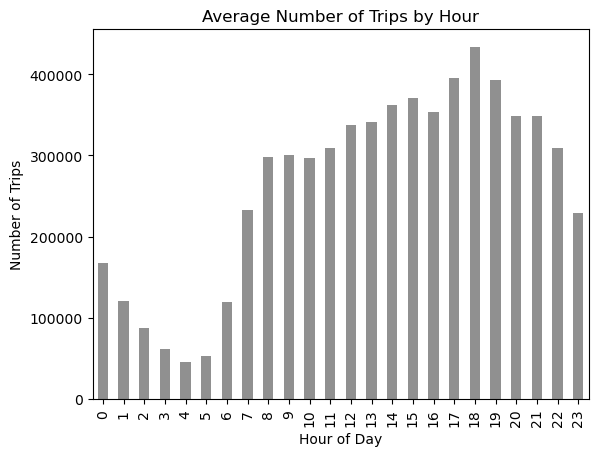

In [45]:

hourly_trips.plot(kind='bar', color = '#909090' )
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Average Number of Trips by Hour')
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\avg_trips_by_hrs.png")
plt.show()


Trip volume peaks during evening hours, indicating higher demand during post-work commuting periods.

More drivers should be allocated during evening peak hours to reduce wait times and maximize completed trips.


### B. Solo vs Group Travelers

Do people mostly travel alone or in groups? What is the most common passenger_count? Does the tip_amount increase if there are more passengers?

In [46]:
taxi_data['passenger_count'].value_counts()

passenger_count
1    4529529
2     942867
3     249397
5     225191
6     131933
4     122970
0     114037
7         29
9         19
8         17
Name: count, dtype: int64

In [47]:
tip_by_passenger = taxi_data.groupby('passenger_count')['tip_amount'].mean()
tip_by_passenger

passenger_count
0    2.122211
1    2.222645
2    2.241239
3    2.168872
4    2.078237
5    2.224711
6    2.237291
7    6.552759
8    4.960000
9    7.793158
Name: tip_amount, dtype: float64

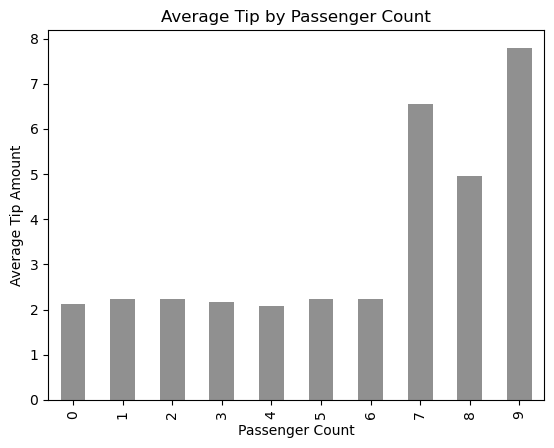

In [49]:
tip_by_passenger.plot(kind='bar', color = '#909090')
plt.xlabel('Passenger Count')
plt.ylabel('Average Tip Amount')
plt.title('Average Tip by Passenger Count')
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\avg_trips_pass_count.png")
plt.show()


Most trips are solo rides. However, trips with higher passenger counts tend to show higher average tips.

Group travelers may be more willing to tip, suggesting opportunities for targeted promotions or larger-vehicle services.

### C. Payment Split

What percentage of our customers pay by Credit Card vs. Cash (payment_type)? Is there a difference in the average tip_amount between card users and cash users?

In [50]:
payment_split = taxi_data['payment_type'].value_counts(normalize=True) * 100
payment_split

payment_type
1    74.327330
2    25.119819
3     0.407426
4     0.145409
5     0.000016
Name: proportion, dtype: float64

In [51]:
avg_tip_payment = taxi_data.groupby('payment_type')['tip_amount'].mean()
avg_tip_payment

payment_type
1    2.985482
2    0.000196
3    0.003783
4    0.001454
5    0.000000
Name: tip_amount, dtype: float64

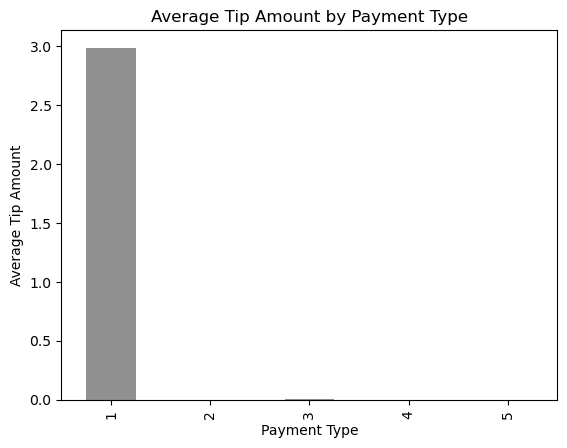

In [52]:
avg_tip_payment.plot(kind='bar', color = '#909090')
plt.xlabel('Payment Type')
plt.ylabel('Average Tip Amount')
plt.title('Average Tip Amount by Payment Type')
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\avg_tip_amt_by_pymentype.png")
plt.show()


Card users tip significantly more than cash users.

Encouraging digital payments could increase driver earnings through higher tipping behavior.

### D. Airport Run

We suspect trips with RatecodeID = 2 (JFK Airport) have a higher average fare than standard city trips (RatecodeID = 1). Can you prove this with data?

In [53]:
fare_by_ratecode = taxi_data.groupby('RatecodeID')['fare_amount'].mean()
fare_by_ratecode

RatecodeID
1     11.121774
2     51.933796
3     63.941701
4     74.246032
5     60.280264
6     29.897907
99    14.549091
Name: fare_amount, dtype: float64

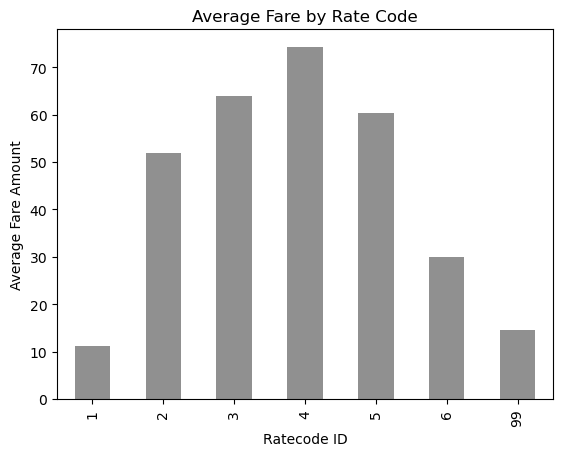

In [55]:
fare_by_ratecode.plot(kind='bar', color = '#909090')
plt.xlabel('Ratecode ID')
plt.ylabel('Average Fare Amount')
plt.title('Average Fare by Rate Code')
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\avg_fr_by_ratecode.png")
plt.show()

Trips associated with JFK Airport show a higher average fare compared to standard city trips.

Drivers could be incentivized to accept airport trips due to their higher revenue potential.

# PHASE 3: The Strategic “So What?” (Storytelling)

### A. Congestion Surcharge

We charge a congestion_surcharge. Does this surcharge discourage people? Compare the trip volume for trips with surcharge vs. without. What is your recommendation? Should we lobby to remove it?

In [56]:
taxi_data.groupby('congestion_surcharge').size()

congestion_surcharge
0.00     473036
0.50          4
0.75         68
2.00          1
2.50    5842804
2.75         76
dtype: int64

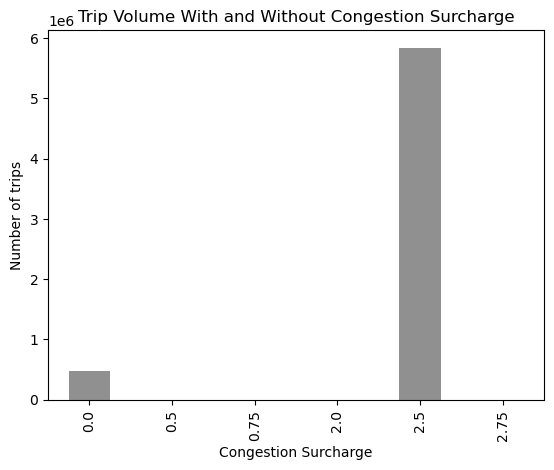

In [57]:
taxi_data.groupby('congestion_surcharge').size().plot(kind = 'bar',color=  '#909090')
plt.xlabel('Congestion Surcharge')
plt.ylabel('Number of trips')
plt.title('Trip Volume With and Without Congestion Surcharge')
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\congestion_chrge.png")
plt.show()

Trips with congestion surcharge still represent a significant portion of total trips, indicating that the surcharge does not strongly discourage demand.

Removing the congestion surcharge is unlikely to increase trip volume significantly and may reduce overall revenue.

### B. “Whale” Pickup Locations

Which Pickup Location (PULocationID) generates the highest total revenue? Identify the Top 3 locations and recommend where we should station our empty taxis.

In [58]:
revenue_by_location = (
    taxi_data.groupby('PULocationID')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(3))
revenue_by_location

PULocationID
132    11359880.31
138     5438279.48
161     4904672.90
Name: total_amount, dtype: float64

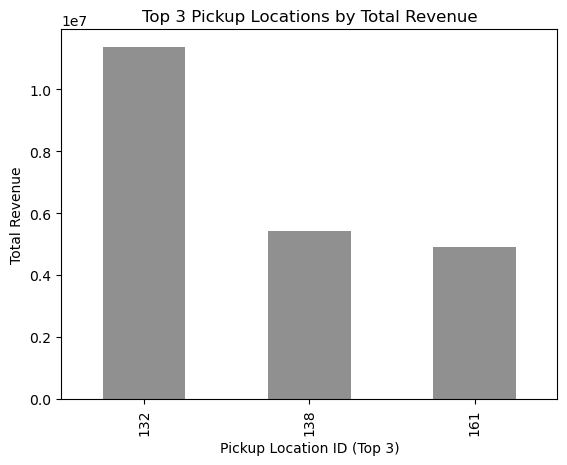

In [59]:
revenue_by_location.plot(kind = 'bar', color = '#909090')
plt.xlabel('Pickup Location ID (Top 3)')
plt.ylabel('Total Revenue')
plt.title('Top 3 Pickup Locations by Total Revenue')
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\top3_pckup_loc.png")
plt.show()

A small number of pickup locations contribute a disproportionately large share of total revenue.

Driver allocation, dynamic pricing strategies, and service optimization should be prioritized in high-revenue pickup zones, particularly Pickup Location 132.
    

### C. Speed Analysis (Rocket Cars)


We suspect some drivers are spoofing GPS. If a trip shows a speed > 100 MPH or < 0 MPH, flag it as 'Data Error'. 

In [60]:
taxi_data['speed_mph'] = taxi_data['trip_distance'] / (
    taxi_data['duration'] / 60)

taxi_data['speed_flag'] = taxi_data['speed_mph'].apply(
    lambda x: 'Data Error' if x > 100 or x < 0 else 'Valid')

taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration,pickup_hour,speed_mph,speed_flag
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1,1.2,1,N,238,239,1,...,0.5,1.47,0.0,0.3,11.27,2.5,4.800000,0,15.000000,Valid
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1,1.2,1,N,239,238,1,...,0.5,1.50,0.0,0.3,12.30,2.5,7.416667,0,9.707865,Valid
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1,0.6,1,N,238,238,1,...,0.5,1.00,0.0,0.3,10.80,2.5,6.183333,0,5.822102,Valid
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1,0.8,1,N,238,151,1,...,0.5,1.36,0.0,0.3,8.16,0.0,4.850000,0,9.896907,Valid
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1,0.0,1,N,193,193,2,...,0.5,0.00,0.0,0.3,4.80,0.0,2.300000,0,0.000000,Valid


Trips exceeding realistic speed thresholds were flagged as data errors, likely due to GPS issues.

# PHASE 5: Vendor Wars (Comparative Analysis)

Compare the Average Tip Amount for Vendor 1 vs. Vendor 2. Does the interface of one machine encourage better tipping? This is a huge potential revenue find for our drivers.

In [61]:
taxi_data['VendorID'] = taxi_data['VendorID'].astype('int')

In [62]:
taxi_data.groupby('VendorID')['tip_amount'].mean()


VendorID
1    2.125673
2    2.265322
Name: tip_amount, dtype: float64

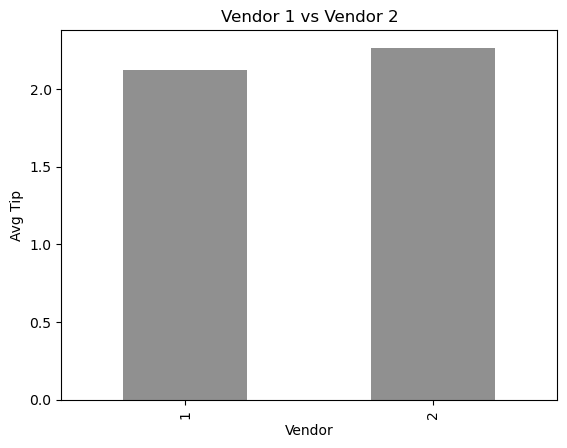

In [64]:
taxi_data.groupby('VendorID')['tip_amount'].mean().plot(kind = 'bar', color = '#909090')
plt.xlabel('Vendor')
plt.ylabel('Avg Tip')
plt.title('Vendor 1 vs Vendor 2')
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\vendor_wars.png")
plt.show()

Vendor 2 shows a higher average tip amount compared to Vendor 1.

The vendor associated with higher tipping may have a more user-friendly interface and should be preferred.

# PHASE 6: Mystery RateCode 99 (Data Detective)

What are these? Are they high value? Low value? Scams? Isolate these rows and tell me what they have in common.

In [65]:
rate_99 = taxi_data[taxi_data['RatecodeID'] == 99]
rate_99.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration,pickup_hour,speed_mph
count,264.000000,264,264,264.000000,264.000000,264.0,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000
mean,1.969697,2020-01-16 13:51:17.314393856,2020-01-16 14:57:57.522727168,1.143939,1.626136,99.0,161.693182,161.814394,1.890152,14.549091,0.576515,0.450758,0.380038,0.162273,0.203409,17.979280,1.704545,66.670139,13.348485,7.829387
min,1.000000,2020-01-01 00:24:18,2020-01-01 00:52:47,0.000000,0.000000,99.0,7.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050000,0.000000,0.000000
25%,2.000000,2020-01-07 23:13:58,2020-01-08 02:54:44.500000,1.000000,0.000000,99.0,132.000000,127.250000,2.000000,3.875000,0.000000,0.500000,0.000000,0.000000,0.000000,7.300000,0.000000,4.429167,11.000000,0.000000
50%,2.000000,2020-01-16 17:59:06,2020-01-16 18:07:17,1.000000,0.620000,99.0,161.000000,161.000000,2.000000,8.000000,0.300000,0.500000,0.000000,0.000000,0.300000,11.800000,2.500000,8.333333,14.000000,6.189163
75%,2.000000,2020-01-24 14:42:13,2020-01-24 15:01:41,1.000000,1.750000,99.0,230.000000,231.000000,2.000000,16.625000,0.800000,0.500000,0.000000,0.000000,0.300000,19.075000,2.500000,15.654167,17.000000,11.250000
max,2.000000,2020-01-31 21:04:18,2020-01-31 21:06:09,4.000000,30.060000,99.0,265.000000,265.000000,2.000000,120.000000,5.300000,0.500000,16.480000,6.120000,0.300000,120.300000,2.500000,4168.000000,23.000000,44.016194
std,0.171745,NaN,NaN,0.605834,3.292136,0.0,65.806784,69.192735,0.313295,17.331870,0.879237,0.149268,1.941267,0.985116,0.140436,18.464796,1.166638,388.614200,5.650781,9.236024


Ratecode 99 trips are rare and display inconsistent fare and distance patterns, suggesting they may represent special cases or data anomalies.
These trips should be reviewed separately.


# PHASE 7: Route Master (Geospatial Logic)

Are the top routes long cross-city trips, or just short hops (e.g., 237 -> 236)? 

In [66]:
taxi_data['route'] = (
    taxi_data['PULocationID'].astype(str) +
    ' -> ' +
    taxi_data['DOLocationID'].astype(str)
)

top_routes = taxi_data['route'].value_counts(normalize=True).head(5)
top_routes

route
237 -> 236    0.007198
236 -> 236    0.006096
236 -> 237    0.006047
237 -> 237    0.005324
264 -> 264    0.004305
Name: proportion, dtype: float64

In [67]:
# Calculating total revenue per route
route_revenue = (
    taxi_data
    .groupby('route')['fare_amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)


# Creating a DataFrame with revenue and average trip distance for top routes
route_analysis = (
    taxi_data
    .groupby('route')
    .agg(
        total_revenue=('fare_amount', 'sum'),
        avg_trip_distance=('trip_distance', 'mean')
    )
    .loc[route_revenue.index]
)
route_analysis

,total_revenue,avg_trip_distance
route,,
264 -> 264,479266.53,2.192241
132 -> 265,405249.11,20.487889
132 -> 230,330296.80,18.193282
237 -> 236,294388.80,1.052923
138 -> 230,279077.50,10.209719


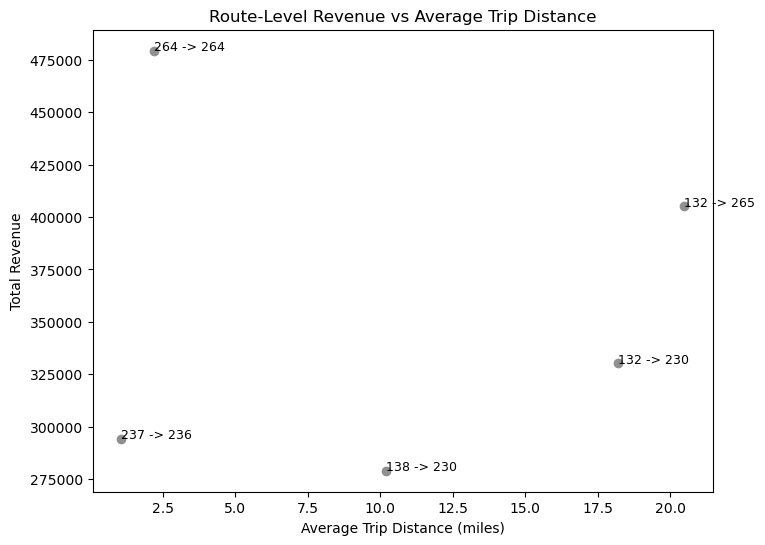

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    route_analysis['avg_trip_distance'],
    route_analysis['total_revenue'], color = '#909090'
)

# Add route labels to each point
for route, row in route_analysis.iterrows():
    plt.text(
        row['avg_trip_distance'],
        row['total_revenue'],
        route,
        fontsize=9
    )

plt.xlabel('Average Trip Distance (miles)')
plt.ylabel('Total Revenue')
plt.title('Route-Level Revenue vs Average Trip Distance')
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\route_lvl_rev_vs_avg_tripdis.png")
plt.show()

The most frequent routes are short-distance trips between nearby locations.

Focus driver allocation and availability on short-distance, high-frequency
routes to maximize trip throughput and overall revenue.

Also, Short-hop routes could be better served by micro-mobility options such as scooters, reducing taxi congestion.

# PHASE 8: Hypothesis Testing

There are so many columns in the dataset, but as per our problem statement, we only require some fields from the original data. Rest columns are nothing but the unwanted columns for this study. So we will simply remove those columns. 

As the problem statement is revolving around the payment type, fare amount, and any other factor influencing the fare amount, we will filter the data to have only passenger count, trip distance, payment type, fare amount and duration of the trip.

In [70]:
# removing unwanted columns
taxi_data.drop(['VendorID','tpep_pickup_datetime','tpep_dropoff_datetime',
                'RatecodeID','store_and_fwd_flag','PULocationID','DOLocationID','extra',
                'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge'
                ,'total_amount','congestion_surcharge', 'pickup_hour', 'speed_mph', 'speed_flag', 'route'],
               axis = 1, inplace = True)
taxi_data.head()

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,1.2,1,6.0,4.800000
1,1,1.2,1,7.0,7.416667
2,1,0.6,1,6.0,6.183333
3,1,0.8,1,5.5,4.850000
4,1,0.0,2,3.5,2.300000


In [71]:
# check for missing values
taxi_data.isnull().sum()

passenger_count    0
trip_distance      0
payment_type       0
fare_amount        0
duration           0
dtype: int64

In [72]:
# removing duplicate rows as they will not contribute in analysis 
taxi_data.drop_duplicates(inplace = True)

In [73]:
# after removing missing values and duplicate rows, now we have this much records left
taxi_data.shape

(2989824, 5)

In [74]:
# passenger count distribution
taxi_data['passenger_count'].value_counts(normalize = True)*100

passenger_count
1    58.113588
2    19.050887
3     6.650157
5     6.315756
6     3.943644
4     3.610915
0     2.312946
7     0.000937
9     0.000602
8     0.000569
Name: proportion, dtype: float64

In [75]:
# payment type distribution
# taxi_data['payment_type'].value_counts()

print(taxi_data['payment_type'].value_counts(normalize = True) * 100)

payment_type
1    68.226591
2    30.815861
3     0.682582
4     0.274933
5     0.000033
Name: proportion, dtype: float64


We will focus solely on payment types 'card' and 'cash,' denoted by 1 and 2 in the dataset. To ensure our analysis centers on these payment methods, we'll filter the data accordingly, excluding all other types.

Moreover, examining the distribution of passenger counts reveals that trips with more than 5 passengers are rare. Additionally, trips with 0 passengers are impossible, as we expect at least one passenger to pay the fare amount. Therefore, we will filter the passenger count to include only values ranging from 1 to 5.

In [76]:
# filtering for payment type 1 and 2
taxi_data = taxi_data[taxi_data['payment_type']<3]

# filtering for passenger count from 1 to 2
taxi_data = taxi_data[(taxi_data['passenger_count']>0)&(taxi_data['passenger_count']<6)]

In [77]:
taxi_data.shape

(2776322, 5)

In [78]:
# replacing the payment type encoded value 1 and 2 to Card and Cash
taxi_data['payment_type'].replace([1,2],['Card','Cash'], inplace = True)

In [79]:
# descriptive statistics for data
taxi_data.describe()

,passenger_count,trip_distance,fare_amount,duration
count,2.776322e+06,2.776322e+06,2.776322e+06,2.776322e+06
mean,1.733952e+00,4.539433e+00,1.784291e+01,2.417540e+01
std,1.177096e+00,4.896137e+00,1.499960e+01,9.264871e+01
min,1.000000e+00,-2.218000e+01,0.000000e+00,1.666667e-02
25%,1.000000e+00,1.500000e+00,9.000000e+00,9.900000e+00
50%,1.000000e+00,2.730000e+00,1.300000e+01,1.573333e+01
75%,2.000000e+00,5.470000e+00,2.100000e+01,2.338333e+01
max,5.000000e+00,2.628800e+02,4.265000e+03,8.525117e+03


Upon reviewing the provided statistics, it's evident that the minimum values for trip distance is negative, which is unrealistic and invalid for further analysis. Consequently, we will eliminate these negative values from the dataset.

Furthermore, observing the maximum and 50th percentile values, it's possible that the data contains significant outliers, particularly high values. These outliers need to be addressed and removed to ensure the integrity of the analysis.

In [80]:
# filtering the records for only positive values
taxi_data = taxi_data[taxi_data['trip_distance']>0]

In [81]:
# descriptive statistics for data
taxi_data.describe()

,passenger_count,trip_distance,fare_amount,duration
count,2.749713e+06,2.749713e+06,2.749713e+06,2.749713e+06
mean,1.738049e+00,4.583384e+00,1.766333e+01,2.418002e+01
std,1.179371e+00,4.899213e+00,1.447632e+01,9.271322e+01
min,1.000000e+00,1.000000e-02,0.000000e+00,1.666667e-02
25%,1.000000e+00,1.530000e+00,9.000000e+00,9.950000e+00
50%,1.000000e+00,2.770000e+00,1.300000e+01,1.575000e+01
75%,2.000000e+00,5.500000e+00,2.100000e+01,2.333333e+01
max,5.000000e+00,2.628800e+02,4.265000e+03,8.525117e+03


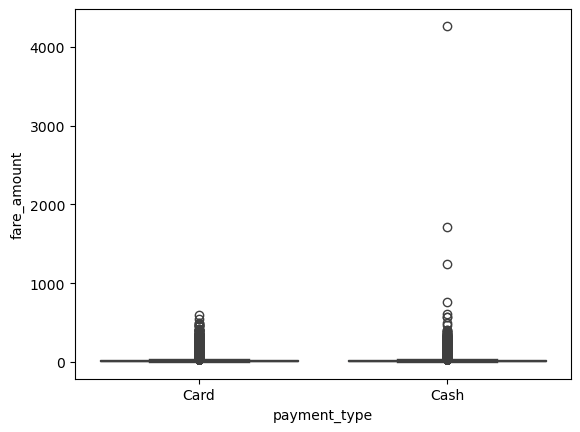

In [82]:
# check for the outliers
sns.boxplot(data=taxi_data, y="fare_amount", x="payment_type")
plt.show()

In [83]:
# removing outliers using interquartile range for the numerical variables
for col in ['trip_distance','fare_amount','duration']:
    Q1 = taxi_data[col].quantile(0.25)
    Q3 = taxi_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    taxi_data = taxi_data[(taxi_data[col] >= lower_bound) & (taxi_data[col] <= upper_bound)]


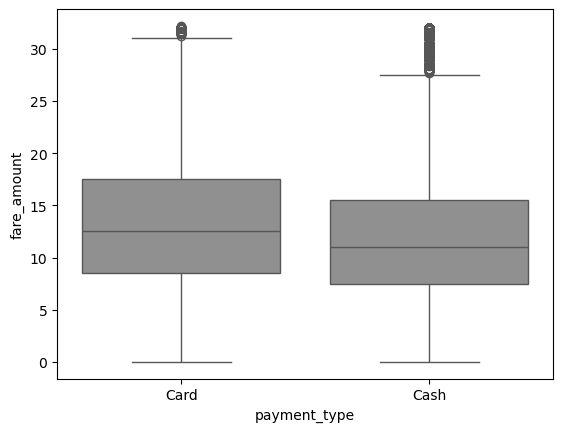

In [84]:
# check for the outliers
sns.boxplot(data=taxi_data, y="fare_amount", x="payment_type", color = '#909090')
plt.show()

We're interested on exploring the relationship between payment type and passenger behavior concerning trip distance and fare amount. Are there variations in the distribution of payment types concerning different fare amounts or trip distances?

To investigate this, we'll plot histograms to visualize the distribution of passenger counts paying with either card or cash. This will also provide stakeholders with insight into fare amount ranges associated with different payment methods.

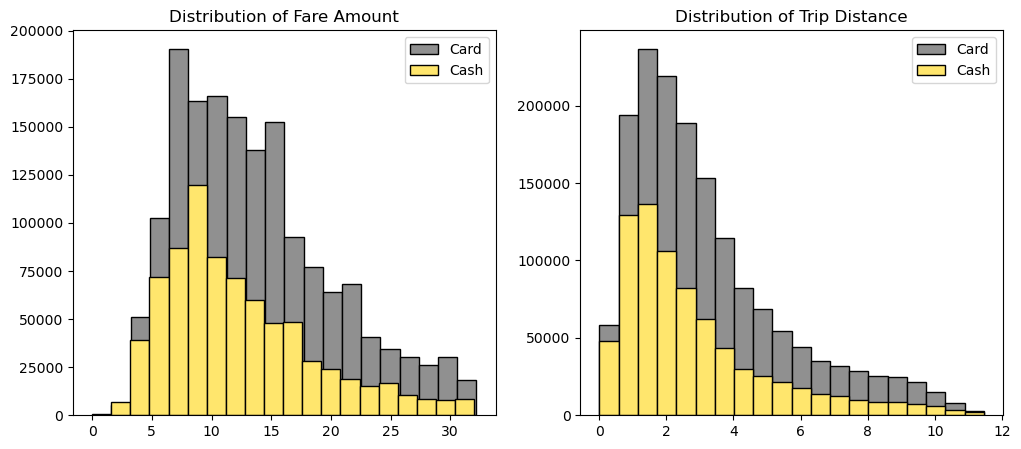

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           13.701254  6.506885      3.230697  2.320562
Cash           12.240976  6.252795      2.803128  2.232100

In [85]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distribution of Fare Amount')
plt.hist(taxi_data[taxi_data['payment_type']=='Card']['fare_amount'], histtype='barstacked', bins = 20, edgecolor = 'k', color = '#909090', label = 'Card')
plt.hist(taxi_data[taxi_data['payment_type']=='Cash']['fare_amount'],  histtype='barstacked',bins = 20, edgecolor = 'k', color = '#FFE66D',label = 'Cash')
plt.legend()

plt.subplot(1,2,2)
plt.title('Distribution of Trip Distance')
plt.hist(taxi_data[taxi_data['payment_type']=='Card']['trip_distance'], histtype='barstacked', bins = 20, edgecolor = 'k',color = '#909090',label = 'Card')
plt.hist(taxi_data[taxi_data['payment_type']=='Cash']['trip_distance'],  histtype='barstacked',bins = 20, edgecolor = 'k', color = '#FFE66D',label = 'Cash')
plt.legend()
plt.show()

# calculating the mean and standard deviation group by on payment type 
taxi_data.groupby('payment_type').agg({'fare_amount': ['mean', 'std',], 'trip_distance': ['mean', 'std']})

In [67]:
pd.cut(taxi_data['fare_amount'], bins=[0,5,10,20,50,100]).groupby(taxi_data['payment_type']).value_counts()

payment_type  fare_amount
Card          (10, 20]       769149
              (5, 10]        483177
              (20, 50]       267628
              (0, 5]          85378
              (50, 100]           0
Cash          (10, 20]       326381
              (5, 10]        285597
              (20, 50]        93536
              (0, 5]          67372
              (50, 100]           0
Name: count, dtype: int64

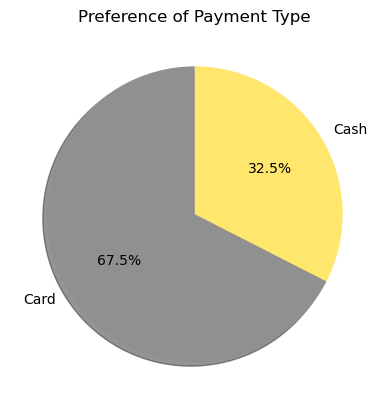

In [86]:
plt.title('Preference of Payment Type')
plt.pie(taxi_data['payment_type'].value_counts(normalize = True), labels = taxi_data['payment_type'].value_counts().index,
       startangle = 90,shadow = True, autopct = '%1.1f%%', colors = ['#909090','#FFE66D'])
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\preference_of_pymttype.png")
plt.show()

Subsequently, we aim to conduct an analysis of the payment types in relation to the passenger count. Our objective is to investigate if there are any changes in preference contingent upon the number of passengers traveling in the cab. 

To facilitate this examination, we have employed a visualization technique known as a stacked bar plot. This method is particularly advantageous for comparing the percentage distribution of each passenger count based on the payment method selected. Through this graphical representation, we can gain insights into potential variations in payment preferences across different passenger counts.

In [87]:
# calculating the total passenger count distribution based on the different payment type
passenger_count = taxi_data.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count

passenger_count
payment_type passenger_count                 
Card         1                         953140
             2                         336571
             3                         124662
             4                          64752
             5                         126283
Cash         1                         476907
             2                         159338
             3                          55521
             4                          33219
             5                          48484

In [88]:
# renaming the passenger_count to count to reset the index
passenger_count.rename(columns = {'passenger_count':'count'},inplace = True)
passenger_count.reset_index(inplace = True)
passenger_count

,payment_type,passenger_count,count
0,Card,1,953140
1,Card,2,336571
2,Card,3,124662
3,Card,4,64752
4,Card,5,126283
5,Cash,1,476907
6,Cash,2,159338
7,Cash,3,55521
8,Cash,4,33219
9,Cash,5,48484


In [89]:
# calculating the percentage of the each passenger count
passenger_count['perc'] = (passenger_count['count']/passenger_count['count'].sum())*100
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,953140,40.066805
1,Card,2,336571,14.148315
2,Card,3,124662,5.240372
3,Card,4,64752,2.721957
4,Card,5,126283,5.308513
5,Cash,1,476907,20.047569
6,Cash,2,159338,6.698034
7,Cash,3,55521,2.333916
8,Cash,4,33219,1.396415
9,Cash,5,48484,2.038105


In [90]:
# creating a new empty dataframe to store the distribution of each payment type (useful for the visualization)
df = pd.DataFrame(columns = ['payment_type',1,2,3,4,5])
df['payment_type'] = ['Card','Cash']
df.iloc[0,1:] = passenger_count.iloc[:5,-1]
df.iloc[1,1:] = passenger_count.iloc[5:,-1]
df

,payment_type,1,2,3,4,5
0,Card,40.066805,14.148315,5.240372,2.721957,5.308513
1,Cash,20.047569,6.698034,2.333916,1.396415,2.038105


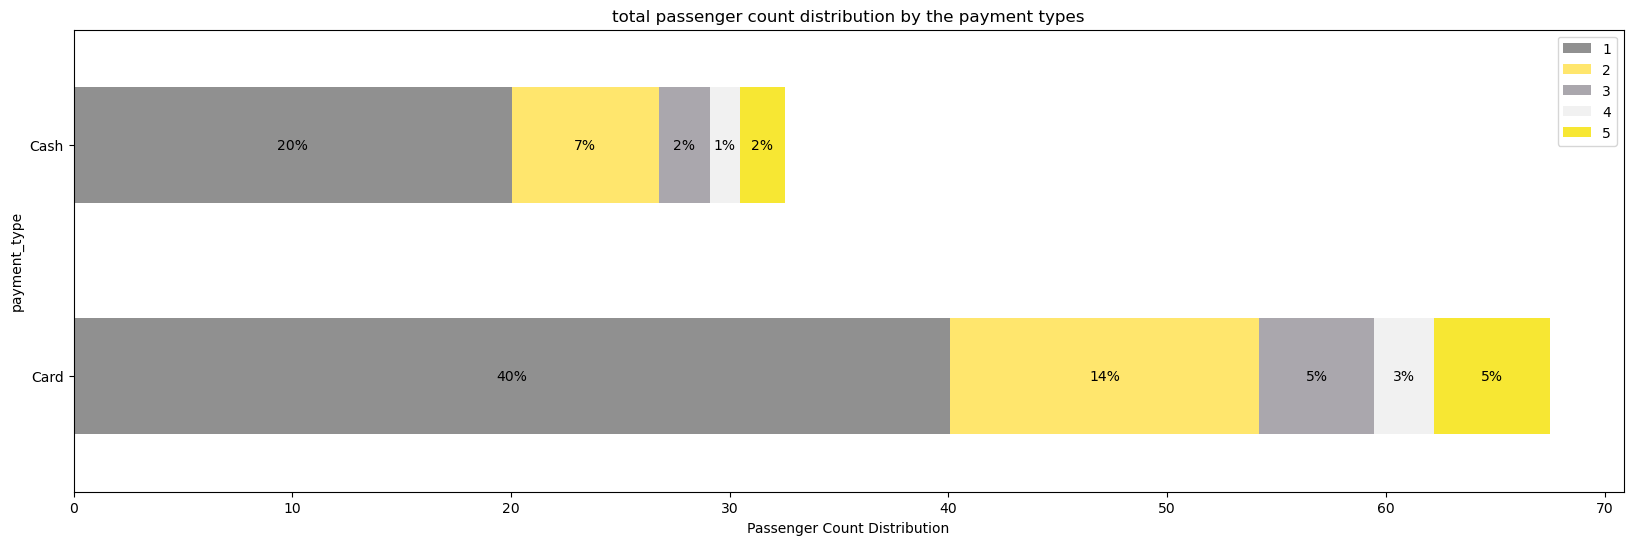

In [92]:
# total passenger count distribution based on the different payment type
fig, ax = plt.subplots(figsize=(20, 6)) 
df.plot(x='payment_type', kind='barh', stacked=True, title=' ', ax=ax, color = ['#909090', '#FFE66D',  '#AAA7AD', '#F1F1F1', '#F7E733'] )
plt.xlabel("Passenger Count Distribution")
plt.title("total passenger count distribution by the payment types")
# Add percentage text
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2,
            y + height / 2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center')
plt.savefig(r"C:\Users\DELL\OneDrive\vinisha_achari\YELLOW_TRIPDATA_PROJECT\WHOLE_PROJECT_DETAILS\images_2\passenger_dist_by_paymttype.png")


### Conducting Hypothesis test

In order to select the most suitable test for our scenario, our initial step involves evaluating whether the distribution of fare amounts adheres to a normal distribution. While the histogram depicted above suggests otherwise, we will further confirm this by generating a QQ plot.

Quantile-quantile (QQ) plots can be used to assess whether the fare amount distributions for each payment type are approximately normally distributed. If the data points closely align with the diagonal line in the plot, it suggests that the data follows a normal distribution.

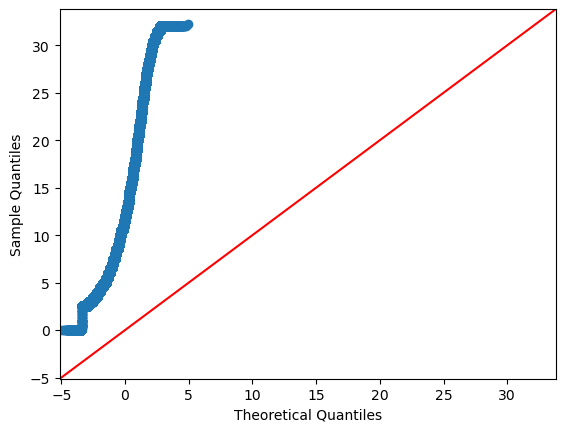

In [93]:
#create Q-Q plot with 45-degree line added to plot
fig = sm.qqplot(taxi_data['fare_amount'], line='45', color = 'black')
plt.show()

The data values clearly do not follow the red 45-degree line, which is an indication that they do not follow a normal distribution. So, z distribution will not be good for this. That's why we will use T test.

Given that the T-test can be applied to both small and large samples and does not require the population standard deviation, it is a more universally applicable approach for hypothesis testing in many practical research scenarios, including analyses of taxi trip data.


In the analysis of NYC Yellow Taxi Trip Records, where you're likely dealing with an unknown population standard deviation and potentially large datasets, the T-test offers a more appropriate and flexible method for comparing means between two groups (e.g., fare amounts by payment type). It provides a reliable way to infer about the population, accommodating the uncertainty that comes with estimating population parameters from sample data.

**H0:** There is no significant difference in average fare between credit card and cash payments.

**H1:** There is a significant difference in average fare between credit card and cash payments.

**α** = 0.05

In [79]:
# sample 1
credit_card = taxi_data[taxi_data['payment_type'] == 'Card']['fare_amount']

# sample 2
cash = taxi_data[taxi_data['payment_type'] == 'Cash']['fare_amount']

# performing t test on both the different sample
t_stat, p_value = stats.ttest_ind(a=credit_card, b=cash, equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

# comparing the p value with the significance of 5% or 0.05
if p_value < 0.05:
    print("\nReject the null hypothesis as p-value < 0.001")
else:
    print("\nAccept the null hypothesis")

T-statistic: 166.49928823989097, P-value: 0.0

Reject the null hypothesis


Since the p-value is significantly smaller than the significance level of 5%, we will reject the null hypothesis.


You conclude that there is a statistically significant difference in the average fare amount between customers who use credit cards and customers who use cash.

The key business insight is that encouraging customers to pay with credit cards can generate more revenue for taxi cab drivers.

While the result is statistically significant, management should also evaluate the magnitude of the difference before making pricing or operational decisions.